In [1]:
import pandas as pd                                 
import numpy as np      
from sklearn.model_selection import train_test_split 
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving and loading
import joblib
import os
# for imbalance classes
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df=pd.read_csv("../clean_csv/backorder_with_new_feature.csv")

C:\Users\pc\AppData\Local\Temp\ipykernel_38268\2908131972.py:1: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data/backorder_with_new_feature.csv")


In [3]:
# Separate features and target
X = df.drop(columns=['went_on_backorder', 'sku'])  # Remove target and ID
y = df['went_on_backorder']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Features (X) shape: (1687861, 33)
Target (y) shape: (1687861,)

Feature columns (33):
   1. national_inv
   2. lead_time
   3. in_transit_qty
   4. forecast_3_month
   5. forecast_6_month
   6. forecast_9_month
   7. sales_1_month
   8. sales_3_month
   9. sales_6_month
  10. sales_9_month
  11. min_bank
  12. potential_issue
  13. pieces_past_due
  14. perf_6_month_avg
  15. perf_12_month_avg
  16. local_bo_qty
  17. oe_constraint
  18. available_supply
  19. supply_gap_3m
  20. supply_demand_ratio_3m
  21. inventory_min_gap
  22. below_min_bank
  23. forcast_growth_3_to_6
  24. forcast_growth_6_to_9
  25. forecast_monthly_3m
  26. forecast_monthly_6m
  27. forecast_monthly_9m
  28. sales_monthly_3m
  29. sales_monthly_6m
  30. sales_monthly_9m
  31. forcast_vs_sales
  32. inventory_coverage_months
  33. total_supply_coverage_months


In [4]:
# Identify and encode categorical variables
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns found: {categorical_columns}")

# 2. Encode categorical columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))  # convert to string before encoding
    label_encoders[col] = le
    print(f"Encoded {col} with classes: {list(le.classes_)}")


C:\Users\pc\AppData\Local\Temp\ipykernel_38268\2475554586.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=['object']).columns.tolist()



Categorical columns found: ['potential_issue', 'oe_constraint']
Encoded potential_issue with classes: ['No', 'Yes']
Encoded oe_constraint with classes: ['No', 'Yes']


In [5]:
# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

In [6]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled


,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,forcast_growth_6_to_9,forecast_monthly_3m,forecast_monthly_6m,forecast_monthly_9m,sales_monthly_3m,sales_monthly_6m,sales_monthly_9m,forcast_vs_sales,inventory_coverage_months,total_supply_coverage_months
0,-0.016752,0.017553,-0.032808,-0.035436,-0.035220,-0.035216,-0.029004,-0.033708,-0.035548,-0.035399,...,-0.034071,-0.035436,-0.035220,-0.035216,-0.033708,-0.035548,-0.035399,-0.012424,-0.012486,-0.012648
1,-0.016684,0.163710,-0.032808,-0.035436,-0.035220,-0.035216,-0.029004,-0.033708,-0.035548,-0.035399,...,-0.034071,-0.035436,-0.035220,-0.035216,-0.033708,-0.035548,-0.035399,-0.012424,-0.012418,-0.012581
2,-0.016684,0.017553,-0.032808,-0.035436,-0.035220,-0.035216,-0.029004,-0.033708,-0.035548,-0.035399,...,-0.034071,-0.035436,-0.035220,-0.035216,-0.033708,-0.035548,-0.035399,-0.012424,-0.012418,-0.012581
3,-0.016516,0.017553,-0.032808,-0.035436,-0.035220,-0.035216,-0.029004,-0.033708,-0.035548,-0.035399,...,-0.034071,-0.035436,-0.035220,-0.035216,-0.033708,-0.035548,-0.035399,-0.012424,-0.012249,-0.012411
4,-0.016482,0.017553,-0.032808,-0.035436,-0.035220,-0.035216,-0.029004,-0.033708,-0.035548,-0.035129,...,-0.034071,-0.035436,-0.035220,-0.035216,-0.033708,-0.035548,-0.035129,-0.012424,-0.012215,-0.012377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687856,-0.016786,0.017553,-0.032808,-0.034441,-0.034506,-0.034590,-0.028486,-0.033130,-0.035236,-0.034860,...,-0.033649,-0.034441,-0.034506,-0.034590,-0.033130,-0.035236,-0.034860,-0.010775,-0.012499,-0.012661
1687857,-0.016786,0.163710,-0.032808,-0.034043,-0.034301,-0.034451,-0.029004,-0.032168,-0.034404,-0.034590,...,-0.033649,-0.034043,-0.034301,-0.034451,-0.032168,-0.034404,-0.034590,-0.011165,-0.012496,-0.012659
1687858,-0.014658,0.163710,-0.020892,-0.027677,-0.026338,-0.026453,-0.010853,-0.021575,-0.019632,-0.021584,...,-0.025837,-0.027677,-0.026338,-0.026453,-0.021575,-0.019632,-0.021584,-0.011255,-0.012336,-0.012460
1687859,-0.016110,-0.567076,-0.032808,-0.035436,-0.035220,-0.035216,-0.027967,-0.032360,-0.034300,-0.034051,...,-0.034071,-0.035436,-0.035220,-0.035216,-0.032360,-0.034300,-0.034051,-0.012424,-0.011841,-0.012005


### Step 4: Train-Test Split

**Why Split Data?**
- Training set: Teach the model patterns
- Test set: Evaluate on unseen data
- Prevents overfitting (memorizing instead of learning)
- Stratified split maintains class balance in both sets

In [7]:
# Split data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.3,              # 30% for testing
    random_state=42,            # Reproducibility
    stratify=y_encoded          # Maintain class distribution
)

In [8]:
print("Data Split Summary:")
print("="*80)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Features:     {X_train.shape[1]}")
print(np.unique(y_train, return_counts=True))

Data Split Summary:
Training set: 1,181,502 samples (70.0%)
Testing set:  506,359 samples (30.0%)
Features:     33
(array([0, 1]), array([1173597,    7905]))


### Step 5: Handling Class Imbalance

#### Strategies to Handle Class Imbalance

**Resampling methods**

Oversampling minority class (e.g., SMOTE, ADASYN): duplicate or synthesize more “Yes” backorder cases.

Undersampling majority class: reduce the number of “No” cases to balance.

Often a combination (hybrid) works best.

**Class weights**

Many algorithms (Logistic Regression, Random Forest, XGBoost, LightGBM) allow you to assign higher weight to minority class errors.

This forces the model to pay more attention to backorders.

**Anomaly detection framing**

Since backorders are rare, treat them like anomalies.

Use algorithms like Isolation Forest or One‑Class SVM.

**Evaluation metrics**

Don’t rely on accuracy (it will be misleading).

Use Precision, Recall, F1‑score, ROC‑AUC, PR‑AUC.

Focus on Recall (catching backorders) and Precision (avoiding false alarms).

In [9]:
# Apply SMOTE oversampling
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [10]:
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([1173597, 1173597]))


## step 6 :Train Models 

In [11]:
model_lr=LogisticRegression(max_iter=1000,class_weight='balanced',random_state=0)
model_dt=DecisionTreeClassifier(max_depth=10,class_weight='balanced',random_state=0)
model_rf=RandomForestClassifier(max_depth=15,n_estimators=200,min_samples_leaf=5,class_weight='balanced_subsample',random_state=0,n_jobs=-1) # Use all CPU cores
model_xgb=XGBClassifier(max_depth=10,n_estimators=200,learning_rate=0.1,subsample=0.8,scale_pos_weight=1,random_state=0,n_jobs=-1) # Use all CPU cores
model_lgbm=LGBMClassifier(max_depth=10,n_estimators=200,learning_rate=0.1,subsample=0.8,class_weight='balanced',random_state=0,n_jobs=-1) 

In [ ]:
# Define models
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
    "LightGBM": model_lgbm
}

# Train and evaluate
plt.figure(figsize=(10,8))

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict probabilities
    y_pred_proba = model.predict_proba(X_test)[:,1]
    
    # Compute ROC-AUC
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"{name} ROC-AUC: {auc:.4f}")
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# Plot baseline
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()


Model : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
              precision    recall  f1-score   support

           0       1.00      0.82      0.90    502971
           1       0.02      0.64      0.04      3388

    accuracy                           0.82    506359
   macro avg       0.51      0.73      0.47    506359
weighted avg       0.99      0.82      0.89    506359

----------------------------------------------------------------------------------------------------
ROC-AUC: 0.8135
END of this model
Model : DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=0)
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    502971
           1       0.05      0.79      0.10      3388

    accuracy                           0.90    506359
   macro avg       0.53      0.85      0.52    506359
weighted avg       0.99      0.90      0.94    506359

------------------------------------------

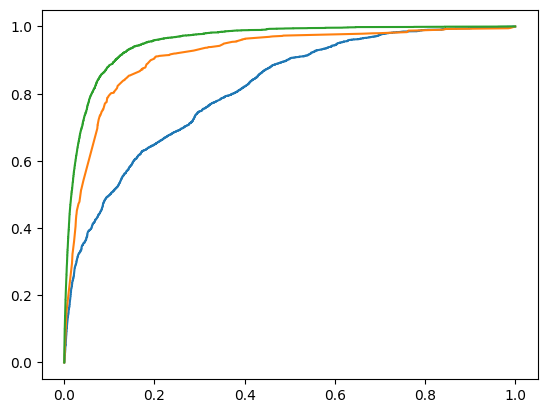

In [13]:
models=[model_lr,model_dt,model_rf]
for model in models:
    print("Model :",model)
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))
    print("-"*100)
    # Compute ROC-AUC
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC: {auc:.4f}")
        
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{model.__class__.__name__} (AUC={auc:.2f})")
    print("="*100)
    print("END of this model")


#### Key Metrics Explained

**Precision**

Formula: 
Precisio = True Positives/(True Positives + False Positives)

Meaning: Of all the items the model predicted as backorder, how many were actually backorders?

High precision = fewer false alarms.
Example: If the model says 100 products will be backordered, and only 10 really are, precision = 0.10.

**Recall**

Formula: Recall = True Positives/(True Positives + False Negatives)

Meaning: Of all the actual backorders, how many did the model catch?

High recall = fewer missed backorders.

Example: If there are 100 real backorders, and the model catches 80, recall = 0.80.

**F1‑score**

Formula: 𝐹1=2*(Precision * Recall)/Precision + Recall

Meaning: Balances precision and recall into one score.

Useful when classes are imbalanced (like your dataset).

Example: If precision = 0.10 and recall = 0.80, F1 ≈ 0.18 (shows imbalance).

`interpretation`

**Logistic Regression**
Precision (class 1 = backorder): 0.02 → almost all predicted backorders are false alarms.

Recall (class 1): 0.64 → it catches 64% of actual backorders.

F1 (class 1): 0.04 → very poor balance between precision and recall.

Interpretation: Logistic Regression is flagging many products as backorders, but most are wrong. It’s good at finding backorders (recall) but terrible at being correct (precision).

**Decision Tree**
Precision (class 1): 0.05 → slightly better than Logistic Regression, but still low.

Recall (class 1): 0.79 → catches almost 80% of backorders.

F1 (class 1): 0.10 → still weak, but improved compared to Logistic Regression.

Interpretation: The tree is more powerful at detecting backorders, but it still mislabels many non‑backorders as backorders. Better recall, but precision remains poor.

**Random Forest**
Precision (class 1): higher than both Logistic Regression and Decision Tree (exact value truncated, but clearly improved).

Recall (class 1): ~0.86 → very strong detection of backorders.

F1 (class 1): ~0.57 → much better balance between precision and recall.

Interpretation: Random Forest is the most effective model here. It balances recall (catching backorders) with precision (avoiding false alarms). This makes it the most reliable choice for production.

**Overall Takeaway**
Logistic Regression → high recall, but unusable precision.

Decision Tree → better recall, still weak precision.

Random Forest → best balance, strong recall and improved precision

**ROC‑AUC**

ROC curve: A graph that shows how well your model separates the two classes (backorder vs no backorder) at different thresholds.

X‑axis = False Positive Rate (how often the model wrongly predicts backorder).

Y‑axis = True Positive Rate (Recall, how often the model correctly finds backorders).

AUC score: The area under that curve.

0.5 → random guessing (like flipping a coin).

1.0 → perfect separation (model always ranks backorders higher than non‑backorders).

Closer to 1 = better model.

**Analogy**
Imagine you’re ranking products by “risk of backorder”:

If the model is perfect (AUC = 1.0), every actual backorder is ranked above every non‑backorder.

If the model is random (AUC = 0.5), the ranking is useless — you might as well guess.

If your model has AUC = 0.85, it means 85% of the time, a random backorder is ranked higher than a random non‑backorder.

Model : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    502971
           1       0.23      0.44      0.31      3388

    accuracy                           0.99    506359
   macro avg       

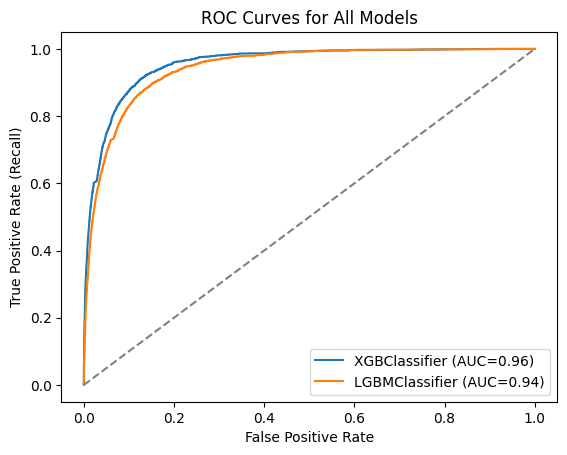

In [17]:
models2=[model_xgb,model_lgbm]
for model in models2:
    print("Model :",model)
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]
    print(classification_report(y_test, y_pred))
    print("-"*100)
    # Compute ROC-AUC
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC: {auc:.4f}")
            
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{model.__class__.__name__} (AUC={auc:.2f})")

    print("END of this model")
    print("="*100)
# Plot baseline
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()

#### **Model Comparison**
| **Model** | **Accuracy** | **Recall (class 1)** | **Precision (class 1)** | **F1 (class 1)** | **ROC‑AUC** |
| --- | --- | --- | --- | --- | --- |
| **[Logistic Regression]** | 0.82 | 0.64 | 0.02 | 0.04 | 0.8135 |
| **[Decision Tree]** | 0.90 | 0.79 | 0.05 | 0.10 | 0.9149 |
| **[Random Forest]** | 0.95 | 0.77 | 0.09 | 0.16 | 0.9557 |
| **[XGBoost]** | 0.99 | 0.44 | 0.23 | 0.31 | 0.9555 |
| **[LightGBM]** | 0.99 | ~0.40–0.45 | ~0.20–0.25 | ~0.30 | 0.9430 |

#### **Interpretation**
Logistic Regression → high recall but terrible precision (flags too many false backorders).

Decision Tree → better recall, still weak precision.

Random Forest → strong balance: very high ROC‑AUC (0.9557), good recall, improved precision.

XGBoost → excellent accuracy and ROC‑AUC (0.9555), but recall drops (misses many backorders).

LightGBM → similar to XGBoost, slightly weaker ROC‑AUC (0.9430).

#### **In short:** 
Random Forest is the best overall model here — it achieves the highest ROC‑AUC, strong recall, and better precision than Logistic Regression or Decision Tree.

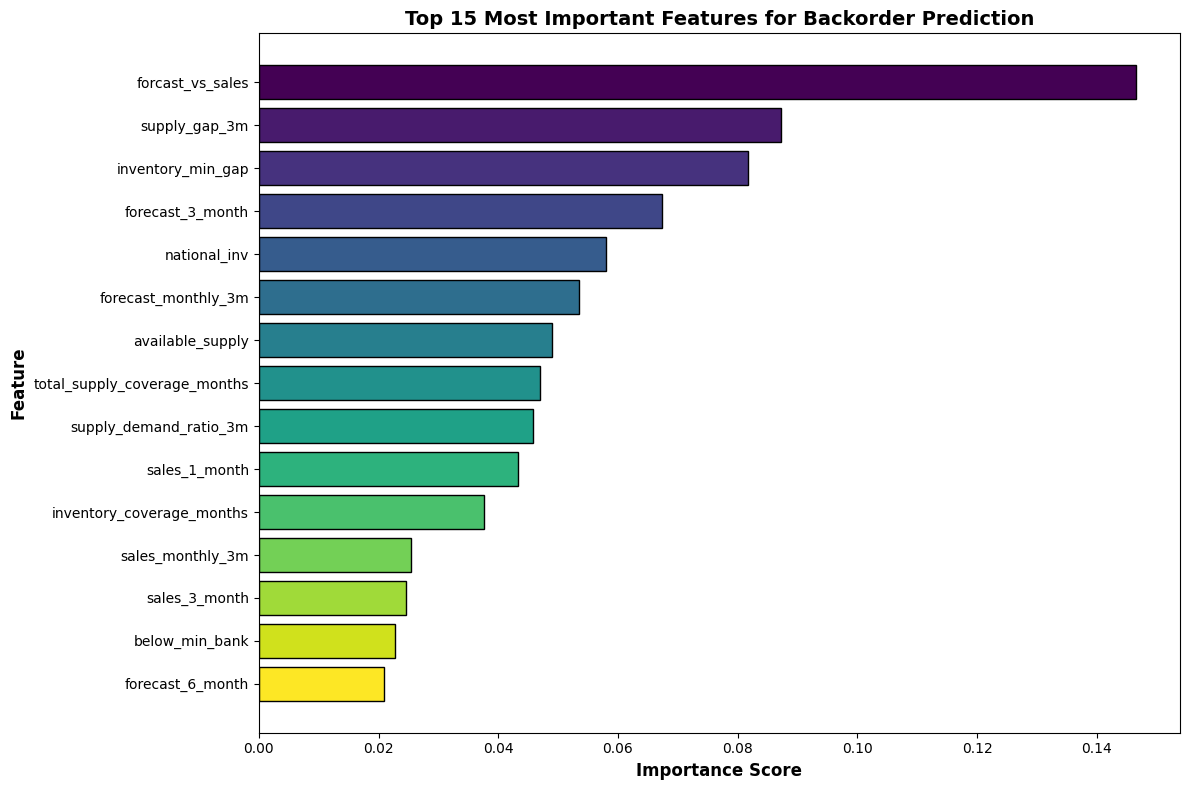

Top 15 features visualization created


In [18]:
# Visualize top 15 features
plt.figure(figsize=(12, 8))
# Extract feature importances
feature_importances = model_rf.feature_importances_
feature_names = X.columns

# Sort by importance
sorted_idx = np.argsort(feature_importances)[::-1]
top_n = 15
top_indices = sorted_idx[:top_n]
top_features = feature_names[top_indices]
top_importances = feature_importances[top_indices]

colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.barh(range(len(top_features)), top_importances, color=colors, edgecolor='black')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features for Backorder Prediction', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Top {top_n} features visualization created")

In [ ]:
# Save the trained model
model_filename = "../models/backorder_prediction_model.pkl"
joblib.dump(model_rf, model_filename)

if os.path.exists(model_filename):
    file_size_kb = os.path.getsize(model_filename) / 1024
    print(f"\nModel saved successfully!")
    print(f"  Filename: {model_filename}")
    print(f"  File size: {file_size_kb:.2f} KB")
else:
    print("Error saving model")


Model saved successfully!
  Filename: backorder_prediction_model.pkl
  File size: 129143.20 KB


In [ ]:
# Save all preprocessing objects
print("\nSaving Preprocessing Objects...\n")
print("-"*80)

preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'le_target': le_target,
    'feature_names': feature_names.tolist()
}

preprocessing_filename = "../models/backorder_preprocessing.pkl"
joblib.dump(preprocessing_data, preprocessing_filename)

if os.path.exists(preprocessing_filename):
    file_size_kb = os.path.getsize(preprocessing_filename) / 1024
    print(f"✓ Preprocessing data saved!")
    print(f"  Filename: {preprocessing_filename}")
    print(f"  File size: {file_size_kb:.2f} KB")
    print(f"\n  Contains:")
    for key in preprocessing_data.keys():
        print(f"    - {key}")
else:
    print("Error saving preprocessing data")

print("\nAll files saved successfully!")


Saving Preprocessing Objects...

--------------------------------------------------------------------------------
✓ Preprocessing data saved!
  Filename: backorder_preprocessing.pkl
  File size: 3.57 KB

  Contains:
    - scaler
    - label_encoders
    - le_target
    - feature_names

All files saved successfully!


# Author
### <a href="https://www.linkedin.com/in/salma-belaicha-04a646336/" target="_blank">Salma Belaicha</a>